In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
RESULTS = "/home/maksym/studia/praca-inzynierska/thesis-2/experiments/quad_convergence/results/d10/bfgs_d10.parquet"
df = pd.read_parquet(RESULTS)
dfs = [d for _, d in df.groupby("run_id")]
df.head(20)

,best_1,best_2,best_3,best_7,best_19,best_25,best_50,best_100,best_187,best_identity,run_id
num_evaluations,,,,,,,,,,,
33,1.527248e+09,1.526829e+09,1.526807e+09,1.524925e+09,1.521777e+09,NaN,NaN,NaN,1.773224e+09,1.527622e+09,1
44,1.180264e+09,1.196863e+09,1.189955e+09,1.321927e+09,1.337066e+09,7.081672e+08,1.519856e+09,1.839627e+09,1.773224e+09,1.142886e+09,1
55,9.907743e+08,9.911816e+08,1.013163e+09,1.104084e+09,NaN,NaN,NaN,1.839627e+09,1.773224e+09,1.092821e+09,1
66,NaN,NaN,NaN,NaN,1.328672e+09,6.621190e+08,1.519856e+09,1.839627e+09,1.773224e+09,NaN,1
77,9.660141e+08,9.700082e+08,9.894304e+08,1.076428e+09,1.327408e+09,NaN,NaN,1.839627e+09,1.773224e+09,1.069929e+09,1
88,NaN,NaN,NaN,NaN,1.325376e+09,6.591868e+08,1.519856e+09,NaN,1.773224e+09,NaN,1
99,9.614796e+08,9.653951e+08,9.849942e+08,1.073425e+09,NaN,NaN,1.519856e+09,1.839627e+09,1.773224e+09,1.066838e+09,1
110,NaN,NaN,NaN,NaN,1.306142e+09,6.580245e+08,1.519856e+09,NaN,1.773224e+09,1.061263e+09,1
121,9.211342e+08,9.215443e+08,9.435552e+08,1.046156e+09,NaN,6.561199e+08,1.519856e+09,1.839627e+09,1.201382e+05,NaN,1


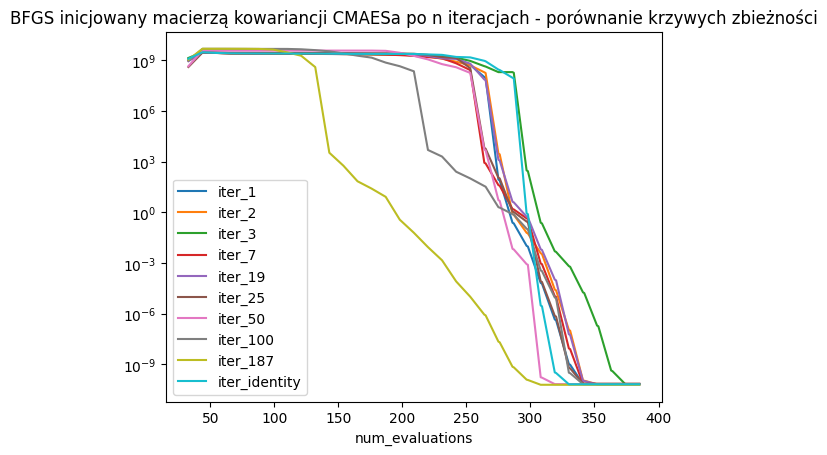

In [6]:
common_index = np.unique(df.index.values)

dfs = [d.reindex(common_index).interpolate(method="index") for d in dfs]
averaged = pd.concat(dfs).groupby(level=0).mean().drop(columns="run_id")
averaged.columns = averaged.columns.str.replace("^best", "iter", regex=True)

# averaged.plot(title="BFGS inicjowany macierzą kowariancji CMAESa po n iteracjach - porównanie krzywych zbieżności")
averaged[averaged.index < 500].plot(title="BFGS inicjowany macierzą kowariancji CMAESa po n iteracjach - porównanie krzywych zbieżności")
plt.yscale("log")
plt.show()

In [ ]:
averaged